# Document Alignment
### This Notebook is for aligning documents to the ir original counter=part.

In [2]:
# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Read Tempalate and Scanned Image

In [3]:
# Define the path to the reference image file using os.path.join for cross-platform compatibility
refFilename = os.path.join("images", "form.jpg")

# Read the reference image in color mode
im1 = cv2.imread(refFilename, cv2.IMREAD_COLOR)

# Convert the reference image from BGR to RGB format
im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)

# Define the path to the image to be aligned using os.path.join for cross-platform compatibility
imFilename = os.path.join("images", "scanned-form.jpg")

# Read the image to be aligned in color mode
im2 = cv2.imread(imFilename, cv2.IMREAD_COLOR)

# Convert the image to be aligned from BGR to RGB format
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)


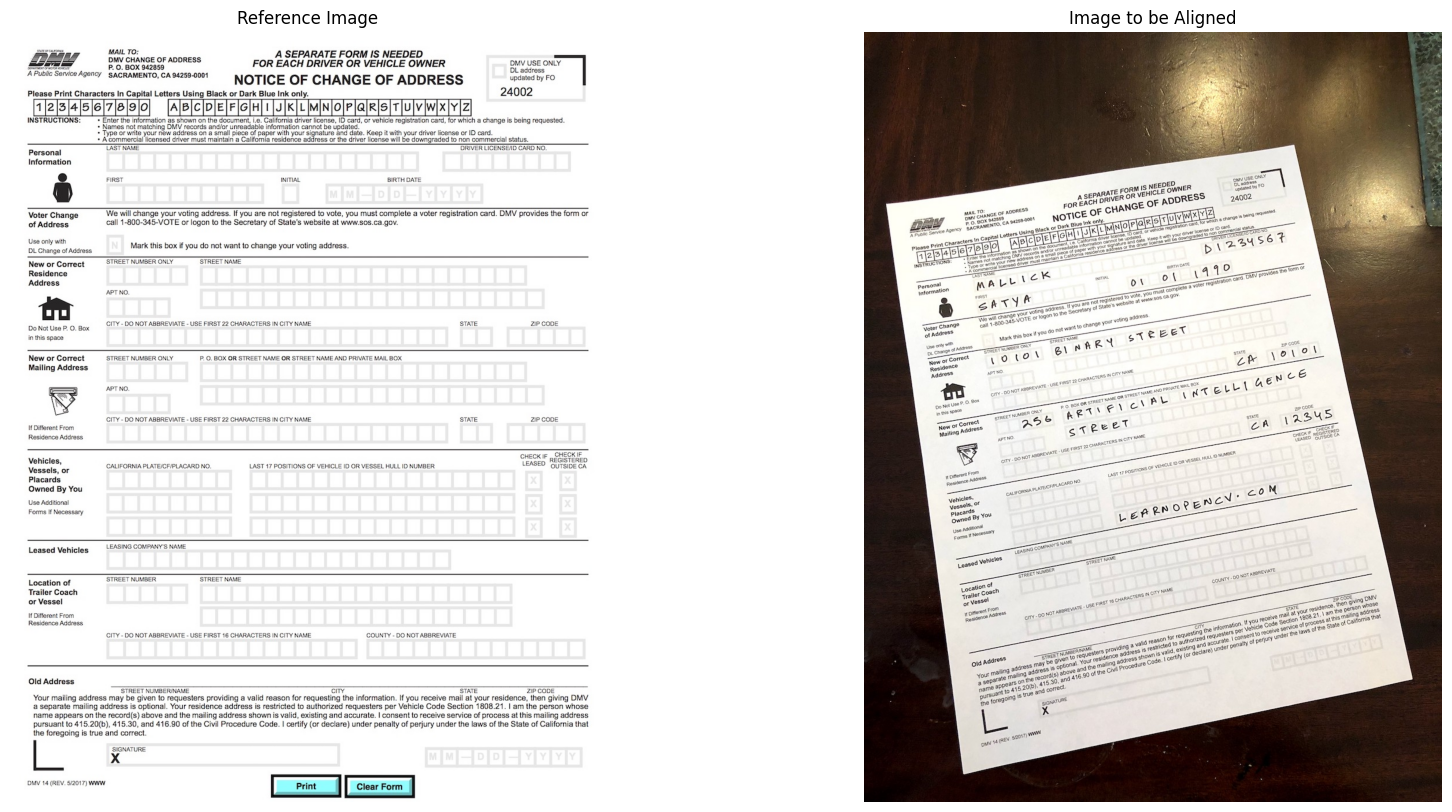

In [5]:
plt.figure(figsize=[20,10])

# Display reference image
plt.subplot(121)
plt.imshow(im1)
plt.title("Reference Image")
plt.axis('off')

# Display image to be aligned
plt.subplot(122)
plt.imshow(im2)
plt.title("Image to be Aligned")
plt.axis('off')

plt.show()

## Step 2: Find keypoints in both Images

Think of keypoints as corner points that are stable under image transformations

In this step, both input images (im1 and im2) are converted from RGB to grayscale using OpenCV’s cv2.cvtColor function. This conversion simplifies the image data and reduces computational complexity, as feature detection algorithms typically work on single-channel images.

Next, the ORB (Oriented FAST and Rotated BRIEF) feature detector is used to identify keypoints and compute corresponding descriptors in both images. ORB is chosen because it is fast, rotation-invariant, and efficient for tasks like image alignment and stitching. The number of features to retain is limited to 500 using MAX_NUM_FEATURES.

keypoints1 and keypoints2 represent the locations of detected features in the grayscale versions of the two images.

descriptors1 and descriptors2 are the binary feature descriptors used to match keypoints between images.

This step lays the groundwork for estimating the transformation needed to align im2 with im1.



In [7]:
# Convert images to grayscale
im1_gray = cv2.cvtColor(im1, cv2.COLOR_RGB2GRAY)
im2_gray = cv2.cvtColor(im2, cv2.COLOR_RGB2GRAY)

# Detect ORB features using OpenCV and compute descriptors.
MAX_NUM_FEATURES = 500
orb = cv2.ORB_create(MAX_NUM_FEATURES)
keypoints1, descriptors1 = orb.detectAndCompute(im1_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(im2_gray, None)

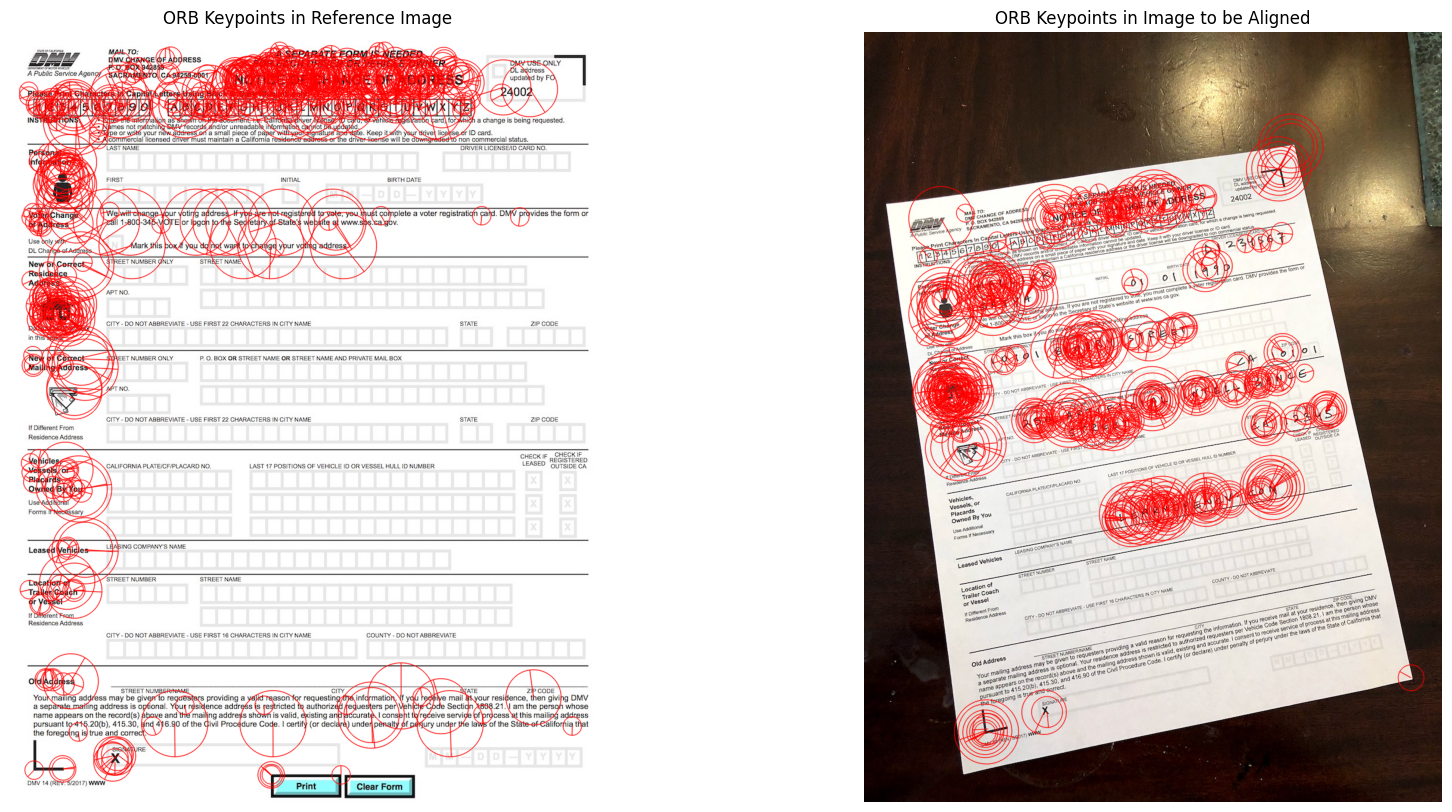

In [9]:
# Display
im1_display = cv2.drawKeypoints(
    im1,
    keypoints1,
    outImage=np.array([]),
    color=(255, 0, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

im2_display = cv2.drawKeypoints(
    im2,
    keypoints2,
    outImage=np.array([]),
    color=(255, 0, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

# Plot
# Plot
plt.figure(figsize=[20, 10])

# Display keypoints for reference image
plt.subplot(121)
plt.imshow(im1_display)
plt.title("ORB Keypoints in Reference Image")
plt.axis('off')

# Display keypoints for image to be aligned
plt.subplot(122)
plt.imshow(im2_display)
plt.title("ORB Keypoints in Image to be Aligned")
plt.axis('off')

plt.show()

## Step 3 : Match keypoints in the two image
This section focuses on matching feature descriptors extracted from the two grayscale images in the previous step:

1. Matcher Initialization:

    A Brute-Force matcher with the Hamming distance metric is created using cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING.

    This is suitable for ORB descriptors, which are binary strings.

2. Descriptor Matching:

    The match() method is called to find the closest match for each descriptor in descriptors1 against descriptors2.

    This yields a list of DMatch objects, each representing a matched pair with a distance score.

3. Match Filtering:

    Matches are sorted by distance to prioritize more similar (i.e., better) matches.

    Only the top 10% of matches are retained using a slicing operation, under the assumption that the best matches are most likely to be correct.

    By filtering out poor matches, this step ensures more reliable keypoint correspondence for the subsequent image alignment.



In [10]:
# Create a DescriptorMatcher object with the BRUTEFORCE_HAMMING algorithm.
# This matcher is used to compare feature descriptors and find the best matches.
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)

# Match the feature descriptors from two images.
# The match() function finds the best matches between descriptors1 and descriptors2.
# The resulting matches are stored in a list.
matches = list(matcher.match(descriptors1, descriptors2, None))

# Sort the matches based on their distance.
# The distance represents how similar the matched descriptors are.
# Sorting in ascending order (reverse=False) means the best matches (lowest distance) come first.
matches.sort(key=lambda x: x.distance, reverse=False)

# Determine the number of good matches to keep.
# Here, we keep the top 10% of matches.
numGoodMatches = int(len(matches) * 0.1)

# Slice the sorted matches to keep only the top 'numGoodMatches'.
matches = matches[:numGoodMatches]


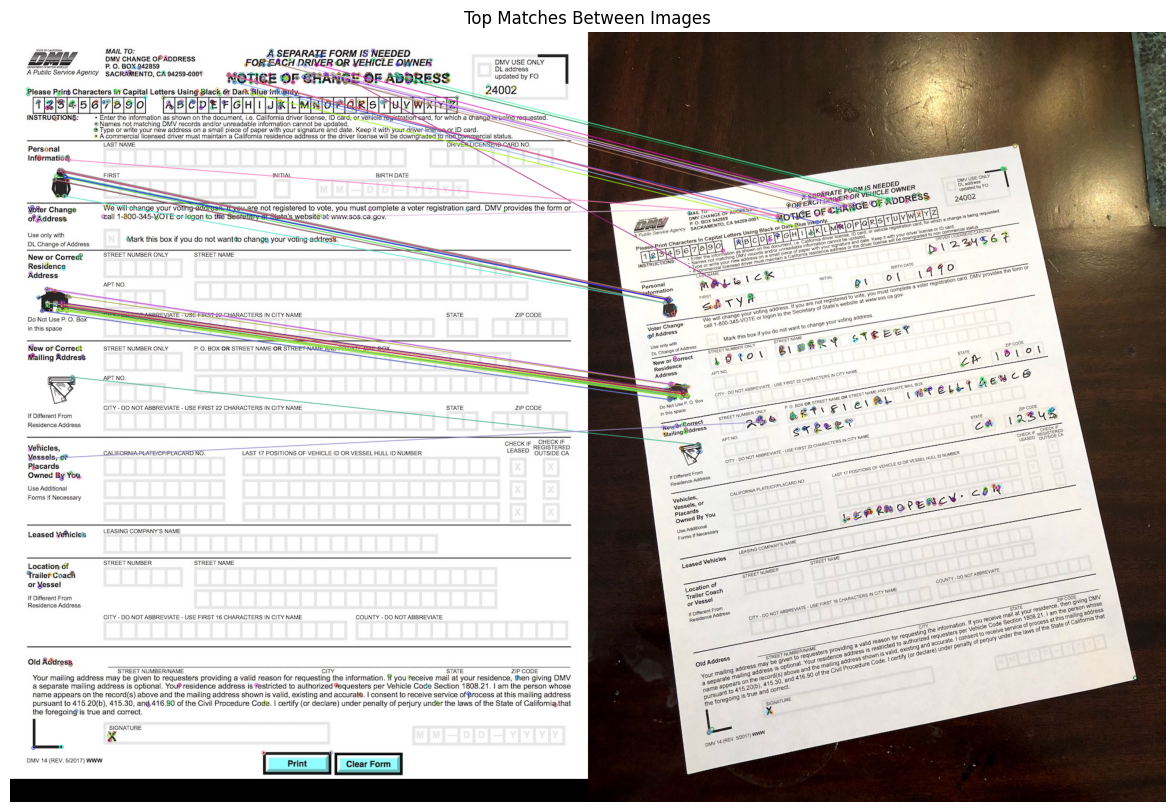

In [11]:
# Draw top matches
im_matches = cv2.drawMatches(im1, keypoints1, im2, keypoints2, matches, None)

# Display im_matches
plt.figure(figsize=(20, 10))
plt.imshow(im_matches)
plt.title("Top Matches Between Images")
plt.axis("off")
plt.show()

## Step 4:  Find Homography
After selecting the best matches, this section extracts the corresponding point coordinates and computes the homography transformation:

Extract Match Coordinates:

Two arrays, points1 and points2, are initialized to store the coordinates of the matched keypoints.

For each good match:

`keypoints1[queryIdx]` gives the location in the first image.

`keypoints2[trainIdx]` gives the corresponding location in the second image.

Estimate Homography with RANSAC:

The cv2.findHomography() function is used to find the best perspective transformation matrix h that maps points2 (from the second image) to points1 (first image).

The RANSAC algorithm is employed to make the estimation robust to outliers.

This homography matrix allows us to geometrically align the second image to the perspective of the first image — a crucial step in image registration and stitching tasks.


In [12]:
# Extract location of good matches
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

# Find homography
h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

## Step 5: Warp image

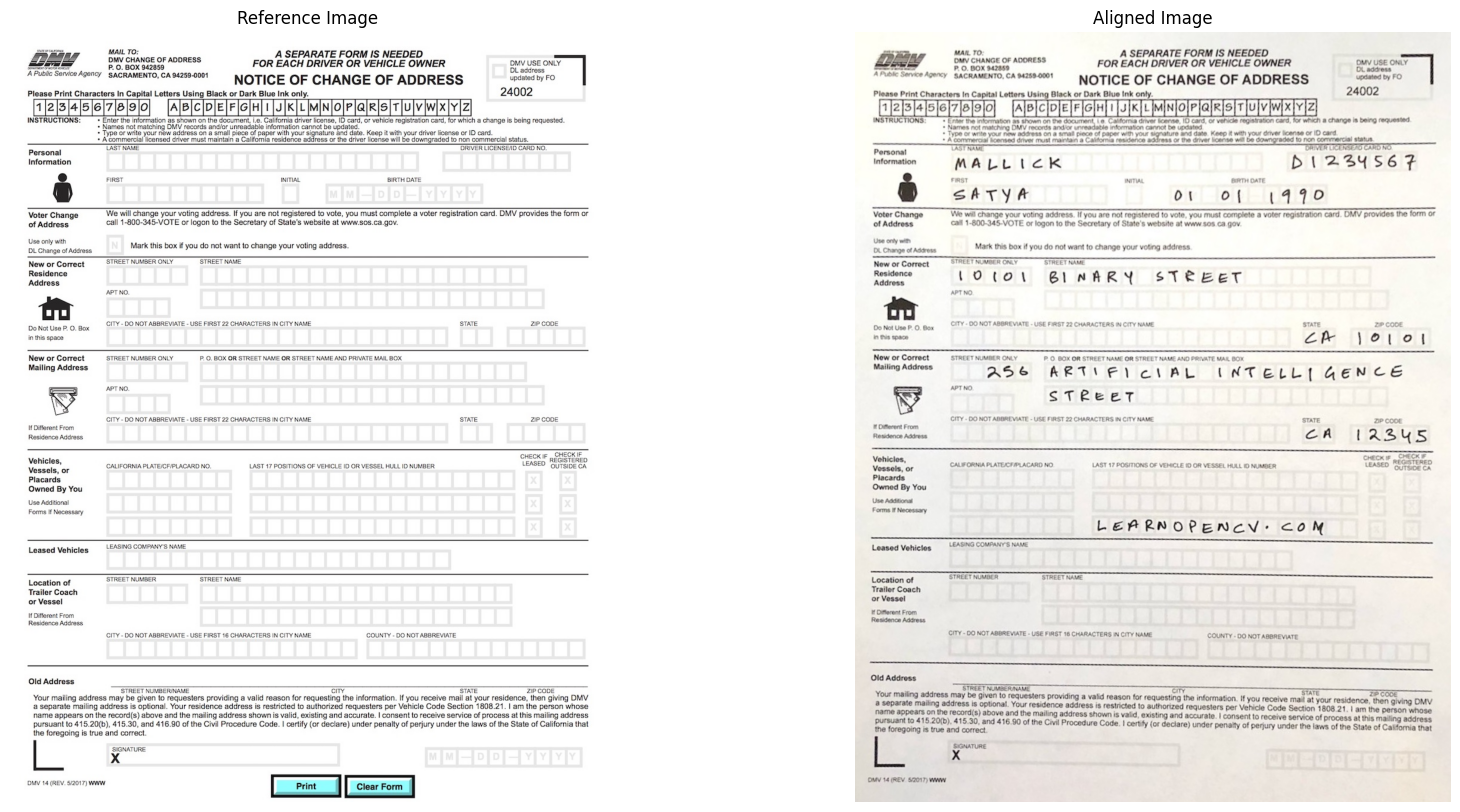

: 

In [ ]:
# Use homography to warp image
height, width, channels = im1.shape
im2_reg = cv2.warpPerspective(im2, h, (width, height))

# Display results
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(im1)
plt.title("Reference Image")
plt.axis("off")

# Aligned image
plt.subplot(1, 2, 2)
plt.imshow(im2_reg)
plt.title("Aligned Image")
plt.axis("off")

plt.show()